# Eksperyment: Test

Test działania eksperymentów.

In [3]:
# === 1. Konfiguracja ===
datasets = {
    "mnist_gelu": {
        "train_images": "../mnist/train-images.idx3-ubyte",
        "train_labels": "../mnist/train-labels.idx1-ubyte",
        "test_images": "../mnist/t10k-images.idx3-ubyte",
        "test_labels": "../mnist/t10k-labels.idx1-ubyte",
        "task": "multiclass",
        "losses": ["categorical_cross_entropy"],
        "activation": "gelu",
        # "activation": "sigmoid",
        "learning_rate": 0.05,
        "hidden_layers": [64, 64, 64, 64, 64],
        "epochs": [30],
        # "optimizer": "adam",
        "optimizer": "momentum",
        "adaptive_lr": False,
        "batching": {
            "minibatch_auto": {
                "batch_size": "auto",
                "shuffle": True,
            },
            # "full_gd": {
            #     "batch_size": None,
            #     "shuffle": False,
            # },
        },
        "early_stopping": True,
        "patience": 5,
    },
}



=== Dataset: MNIST_GELU ===

--- Batching: MINIBATCH_AUTO ---

>>> Loss=categorical_cross_entropy, Epochs=30, Batching=minibatch_auto
>>> Initializing MLP...
Layer sizes: [784, 64, 64, 64, 64, 64, 10], Task: multiclass, Activation: gelu, Optimizer: momentum
>>> Version 16 (mini-batch + early stopping)...
[epoch     1/30] loss=0.604560 acc=0.9336 lr=0.05
[epoch     2/30] loss=0.204748 acc=0.9464 lr=0.05
[epoch     3/30] loss=0.157517 acc=0.9585 lr=0.05
[epoch     4/30] loss=0.126312 acc=0.9613 lr=0.05
[epoch     5/30] loss=0.108034 acc=0.9731 lr=0.05
[epoch     6/30] loss=0.095005 acc=0.9744 lr=0.05
[epoch     7/30] loss=0.082959 acc=0.9756 lr=0.05
[epoch     8/30] loss=0.074171 acc=0.9776 lr=0.05
[epoch     9/30] loss=0.065089 acc=0.9839 lr=0.05
[epoch    10/30] loss=0.058606 acc=0.9844 lr=0.05
[epoch    11/30] loss=0.052747 acc=0.9854 lr=0.05
[epoch    12/30] loss=0.049261 acc=0.9892 lr=0.05
[epoch    13/30] loss=0.043484 acc=0.9906 lr=0.05
[epoch    14/30] loss=0.040722 acc=0.9906 l

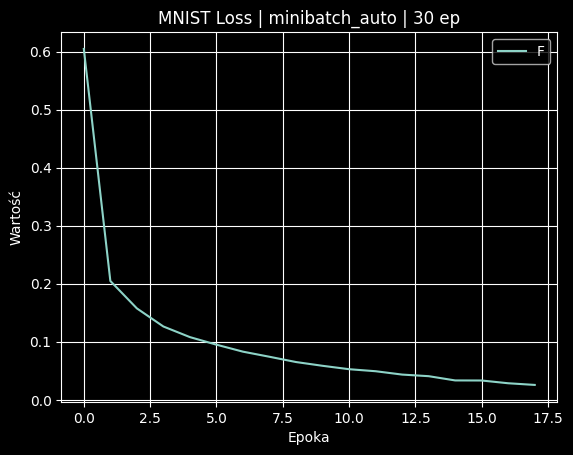

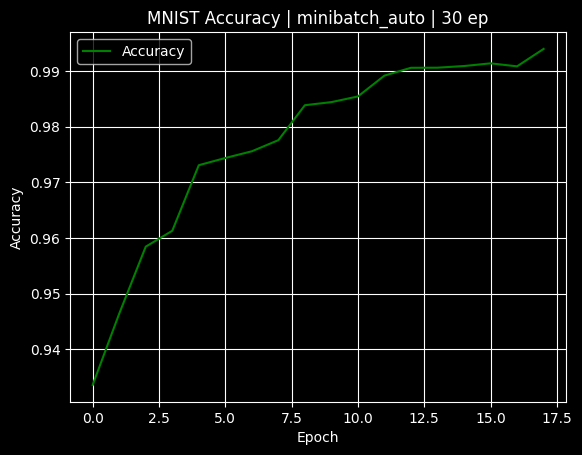

In [4]:
from mlp.mlp import MLP
from mlp.utils import (
    load_mnist_images,
    load_mnist_labels,
    plot_loss,
    plot_accuracy
)
import numpy as np

for dataset_name, cfg in datasets.items():
    print(f"\n=== Dataset: {dataset_name.upper()} ===")

    X_train = load_mnist_images(cfg["train_images"])
    y_train = load_mnist_labels(cfg["train_labels"])
    X_test = load_mnist_images(cfg["test_images"])
    y_test = load_mnist_labels(cfg["test_labels"])

    n_inputs = X_train.shape[1]
    n_classes = 10

    for batching_name, batching_cfg in cfg["batching"].items():
        print(f"\n--- Batching: {batching_name.upper()} ---")

        for loss_name in cfg["losses"]:
            for epoch_count in cfg["epochs"]:
                print(
                    f"\n>>> Loss={loss_name}, "
                    f"Epochs={epoch_count}, "
                    f"Batching={batching_name}"
                )

                model = MLP(
                    layer_sizes=[n_inputs, *cfg["hidden_layers"], n_classes],
                    task=cfg["task"],
                    activation=cfg["activation"],
                    learning_rate=cfg["learning_rate"],
                    seed=42,
                    loss=loss_name,
                    optimizer=cfg["optimizer"] if "optimizer" in cfg else "sgd",
                    adaptive_lr=cfg.get("adaptive_lr", False),
                    lr_decay=0.999
                )

                history, weight_hist, acc_hist = model.fit(
                    X_train,
                    y_train,
                    epochs=epoch_count,
                    batch_size=batching_cfg["batch_size"],
                    shuffle=batching_cfg["shuffle"],
                    verbose=True,
                    use_tqdm=False,
                    early_stopping=cfg["early_stopping"],
                    patience=cfg["patience"],
                )

                # --- Evaluation (UNCHANGED) ---
                y_pred = model.predict(X_test)
                acc = np.mean(y_pred.ravel() == y_test.ravel())
                print(f"Test accuracy: {acc:.4f}")

                plot_loss(
                    history,
                    title=f"MNIST Loss | {batching_name} | {epoch_count} ep"
                )
                plot_accuracy(
                    acc_hist,
                    title=f"MNIST Accuracy | {batching_name} | {epoch_count} ep"
                )
